In [1]:
# import modules
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# load data
with open('../../data/pickles/expdf.p', 'rb') as file:
    expdf = pickle.load(file)

with open('../../data/pickles/id_maps.p', 'rb') as file:
    id_maps = pickle.load(file)

In [3]:
# dataframe with categorical responses converted to integers 
catdf = expdf.copy(deep=True).drop('postqtime', axis = 1).loc[:,expdf.columns[24]:]

responses = [['Very sluggish', 'Very boring','Very difficult','Not well at all','Very tired'],
            ['A little sluggish','A little boring','Somewhat difficult','Not very well','A little tired'],
            ['Neutral'], ['A little alert','A little engaging','Somewhat easy','Somewhat well'],
            ['Very alert', 'Very engaging','Very easy','Very well']]
replacements = [i for i in range(1,6)]

for response, replacement in zip(responses, replacements):
    catdf = catdf.where(~catdf.isin(response), replacement)
    
catdf = pd.concat([expdf.copy(deep=True).drop('postqtime', axis = 1).loc[:,:expdf.columns[23]], catdf.astype(float)], axis=1,
                  sort=False)

## responses for session 1

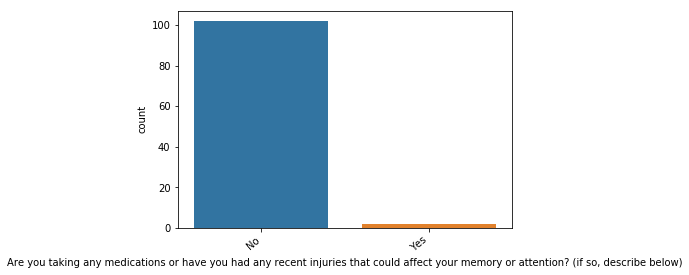

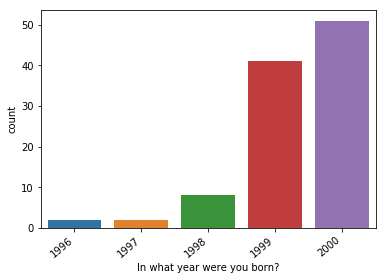

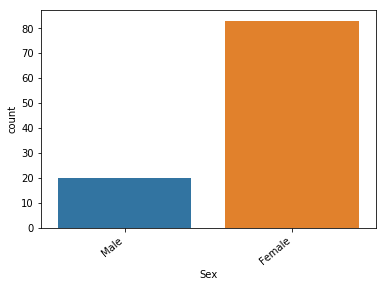

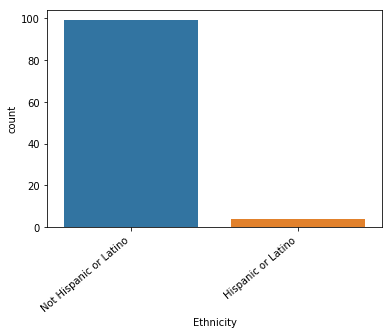

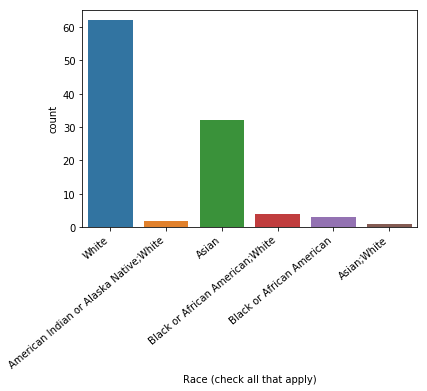

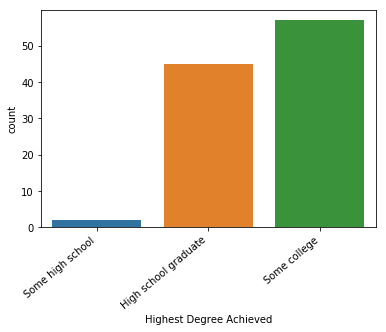

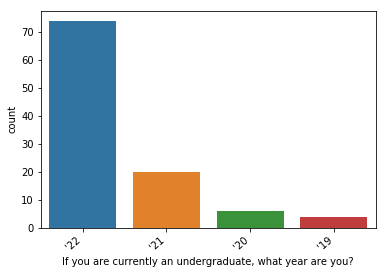

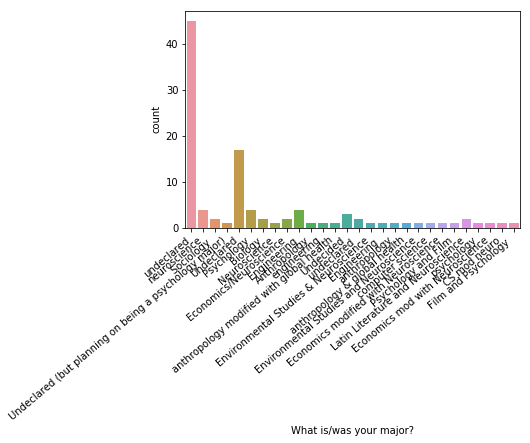

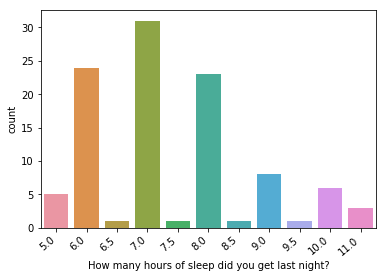

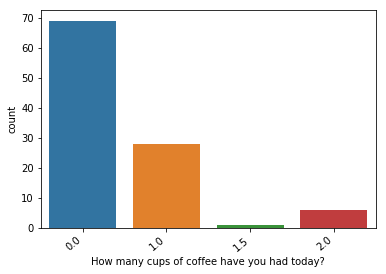

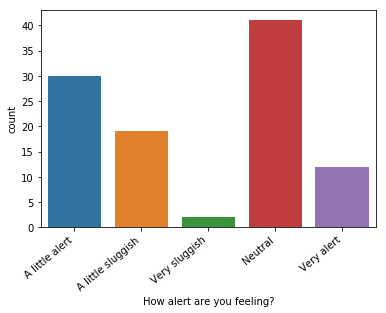

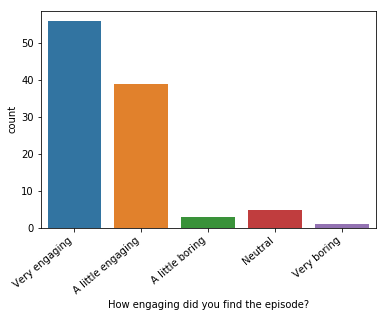

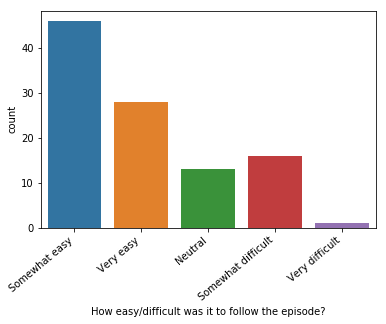

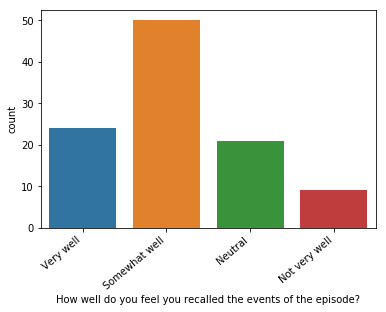

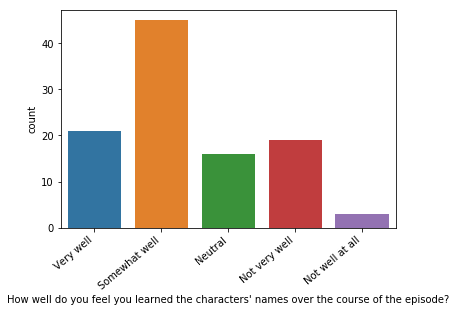

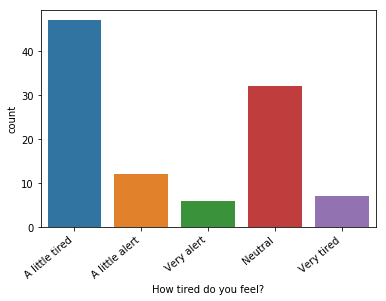

In [4]:
dropcols = ['If yes above, describe','postqtime']
for i, col in enumerate(expdf.drop_duplicates('Subject ID').drop(dropcols, axis=1).columns[13:]):
    plt.figure(i)
    ax = sns.countplot(x=col, data=expdf)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    plt.show()

## relationships between responses for session 1

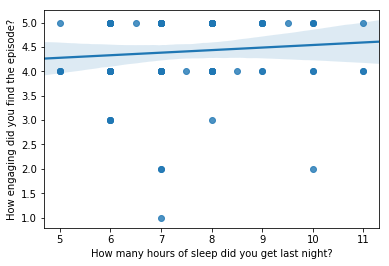

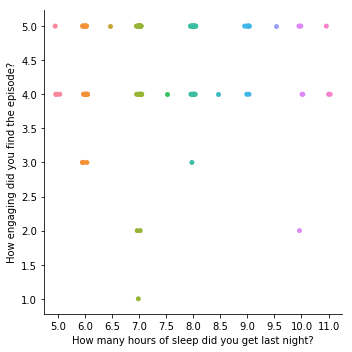

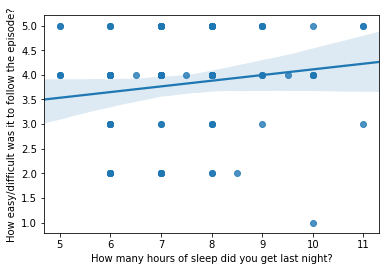

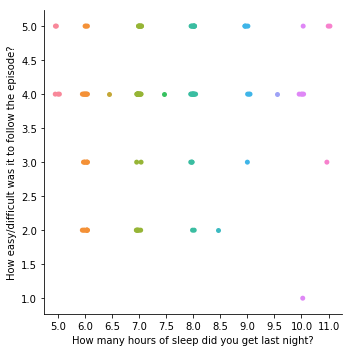

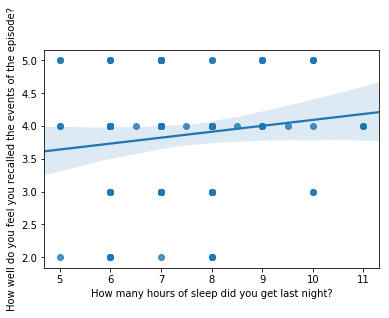

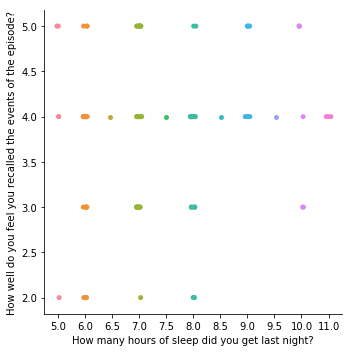

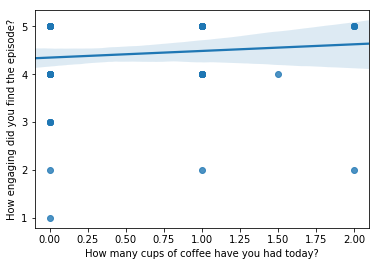

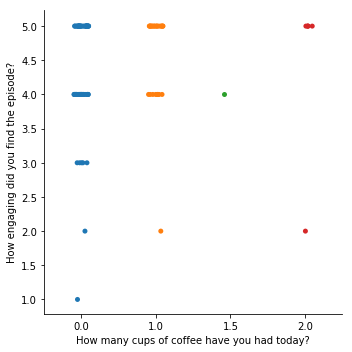

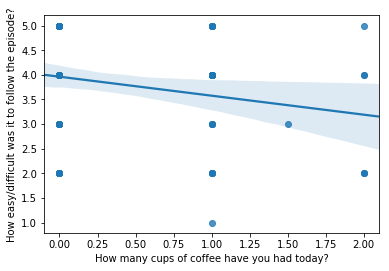

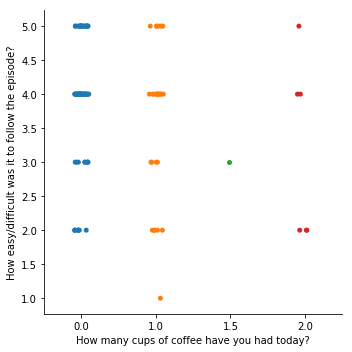

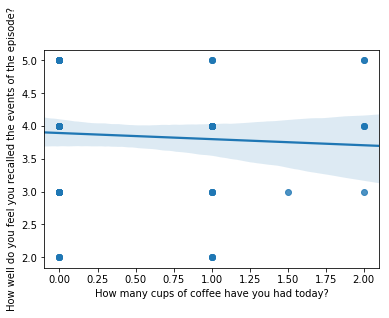

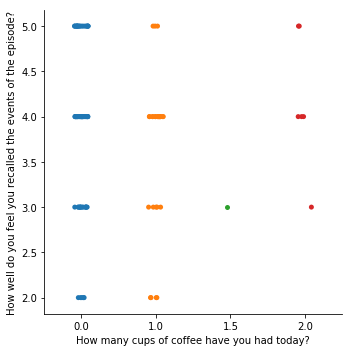

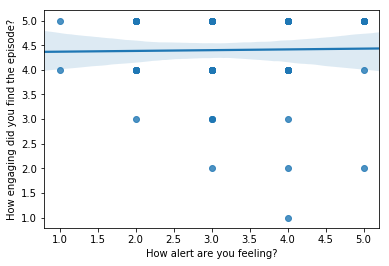

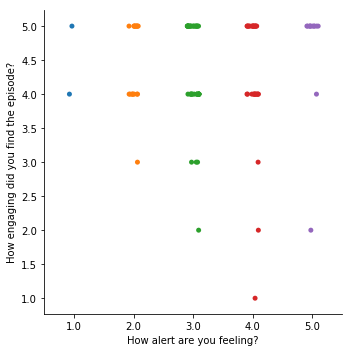

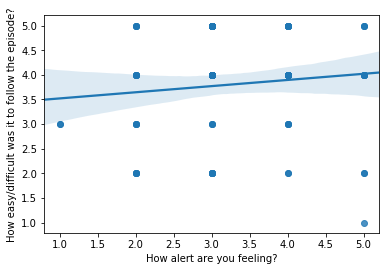

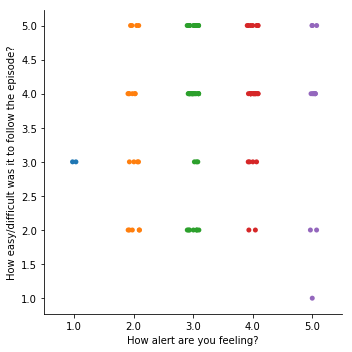

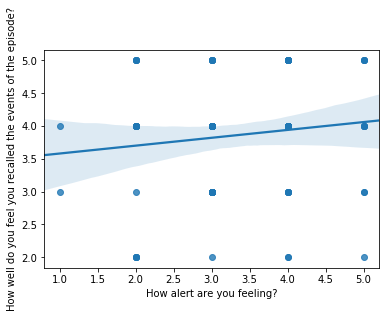

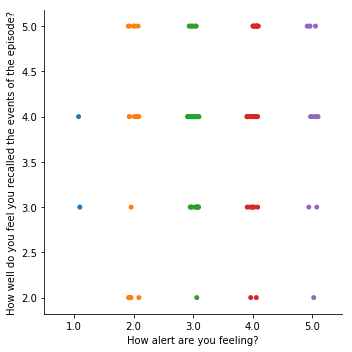

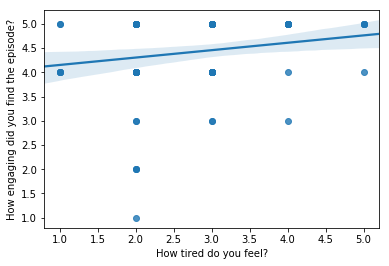

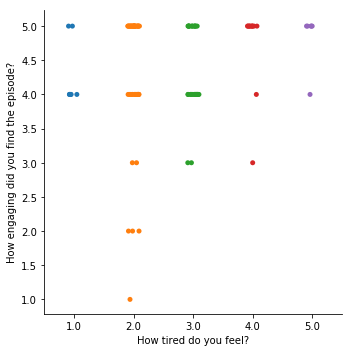

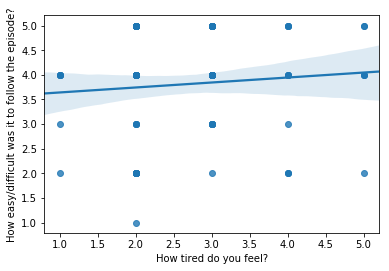

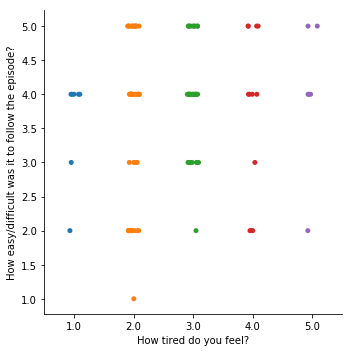

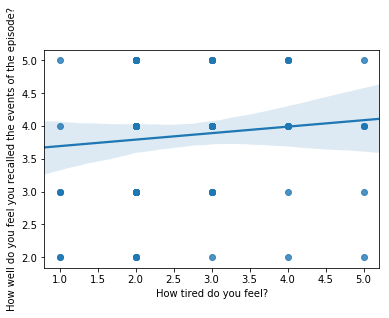

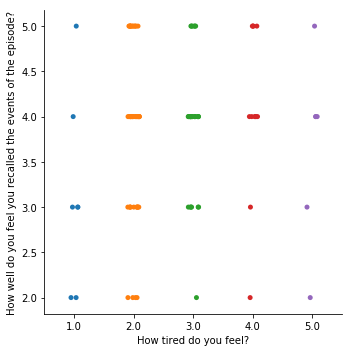

In [5]:
indcolslice = np.r_[21:24,28]
indcols = catdf.drop_duplicates('Subject ID').drop('If yes above, describe', axis=1).columns[indcolslice]
depcols = catdf.drop_duplicates('Subject ID').drop('If yes above, describe', axis=1).columns[24:27]
for indcol in indcols:
    for i, depcol in enumerate(depcols):
        plt.figure(i)
        sns.regplot(x=catdf[indcol].astype(float), y=catdf[depcol].astype(float), data=catdf)
        sns.catplot(x=indcol, y=depcol, data=catdf)
        plt.show()

## responses for session 2

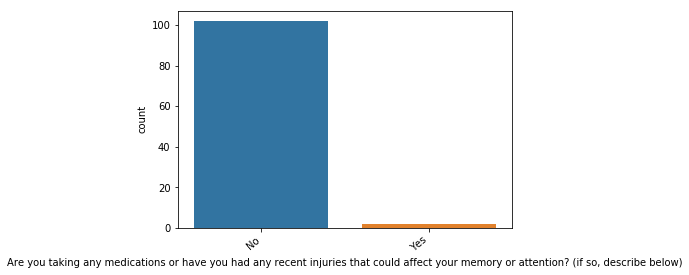

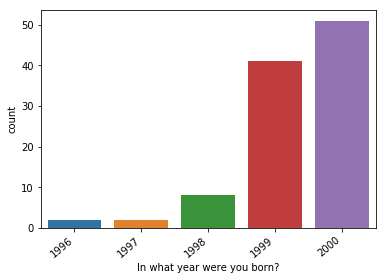

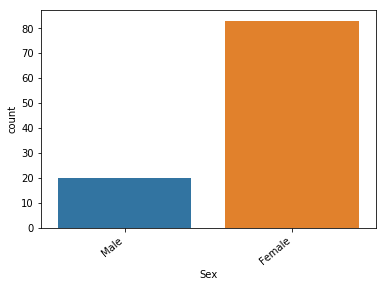

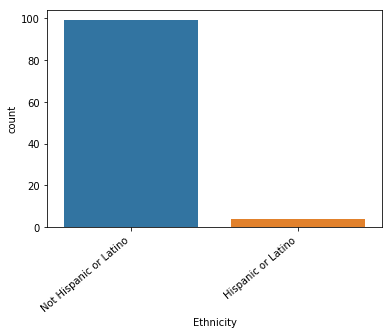

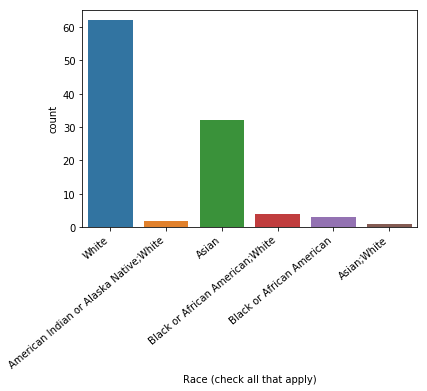

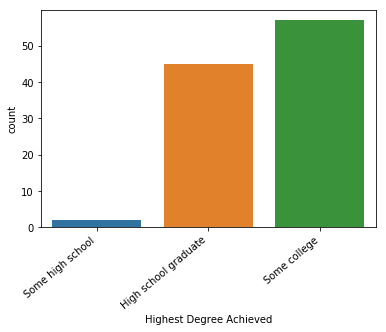

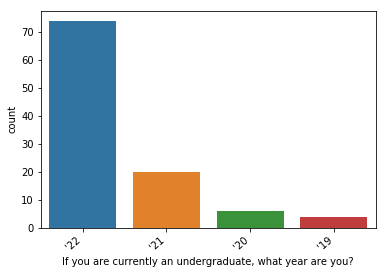

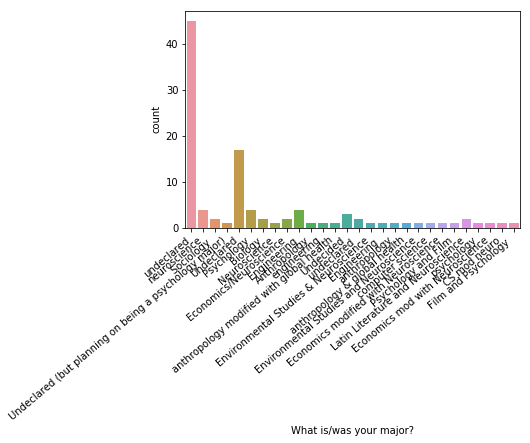

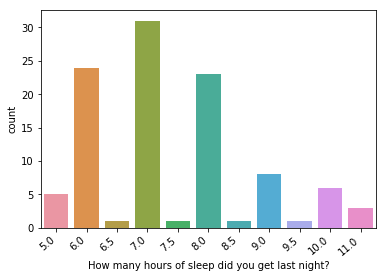

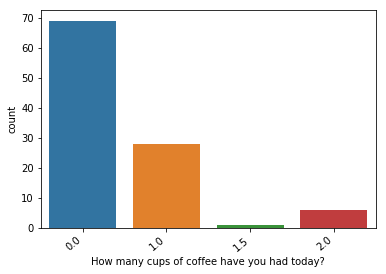

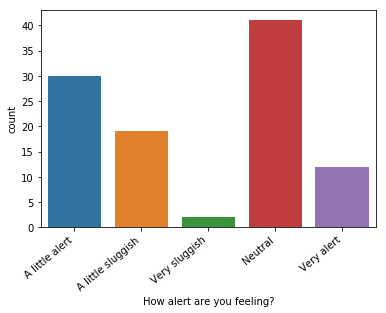

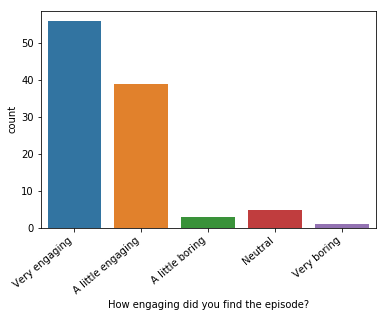

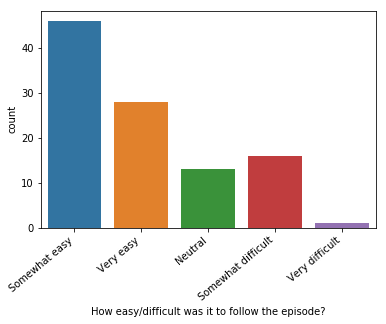

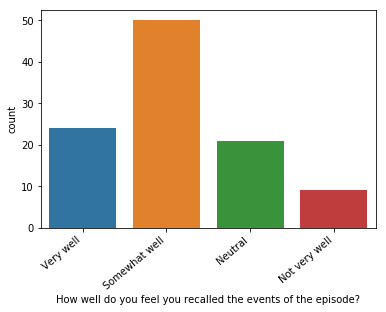

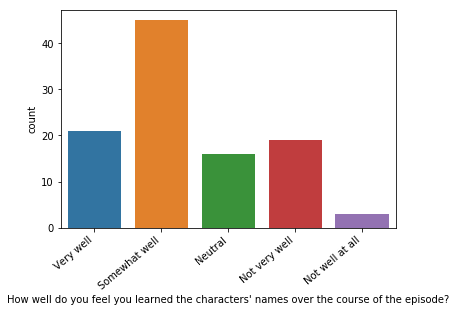

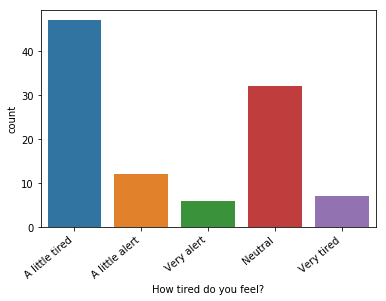

In [6]:
dropcols = ['If yes above, describe','postqtime']
for i, col in enumerate(expdf.drop_duplicates('Subject ID', keep='last').drop(dropcols, axis=1).columns[13:]):
    plt.figure(i)
    ax = sns.countplot(x=col, data=expdf)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    plt.show()

## relationships between responses for session 2

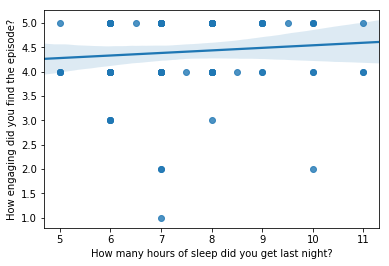

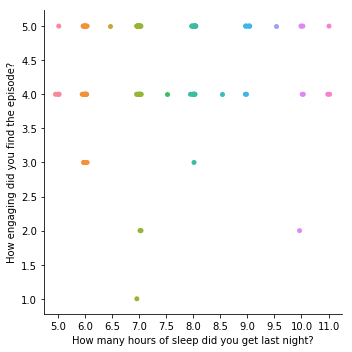

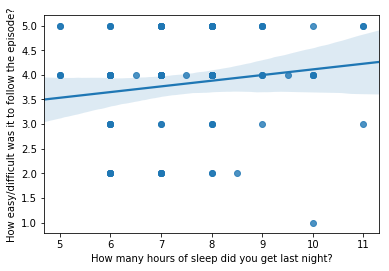

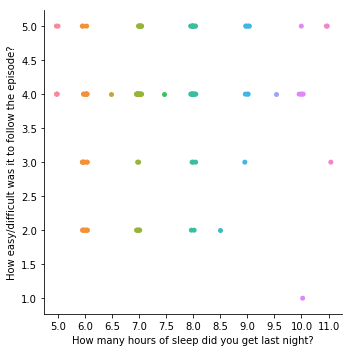

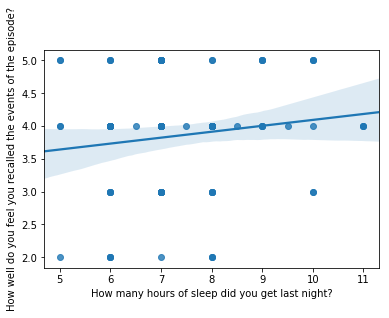

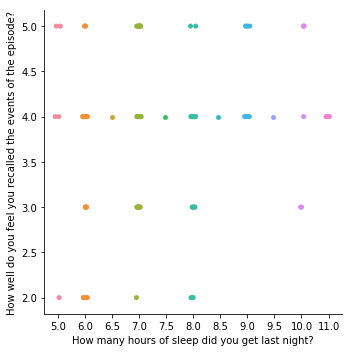

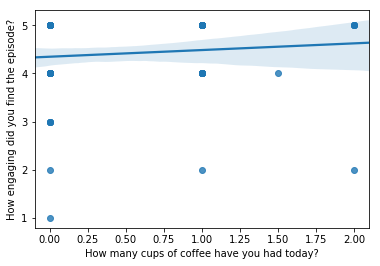

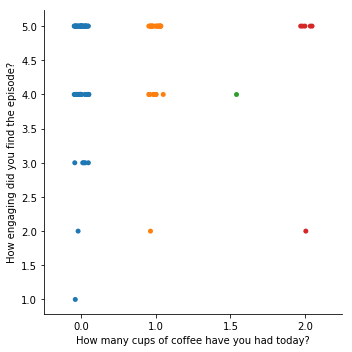

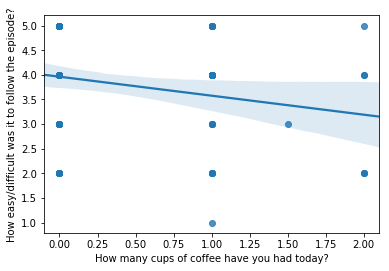

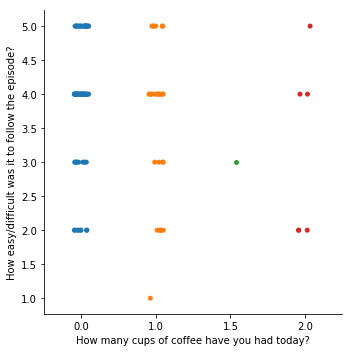

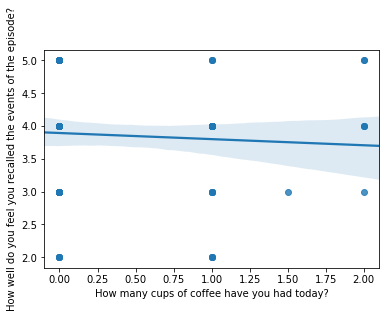

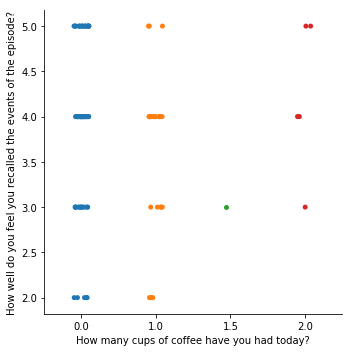

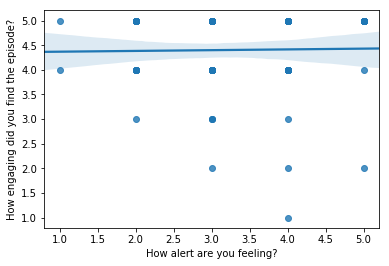

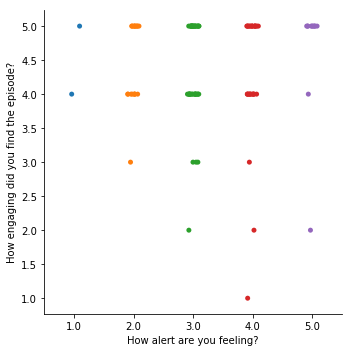

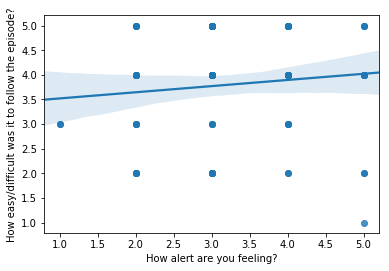

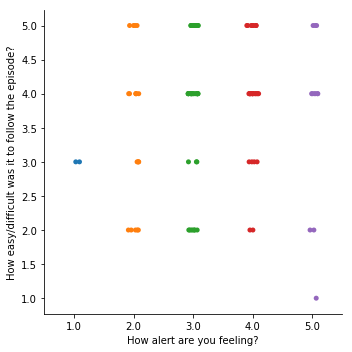

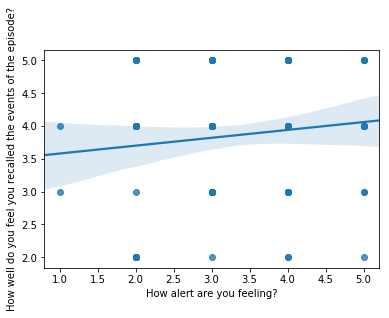

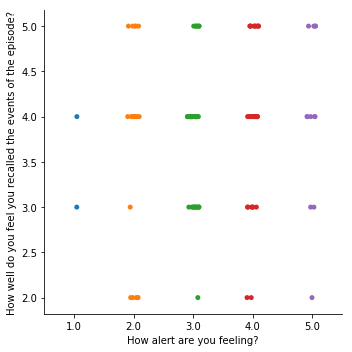

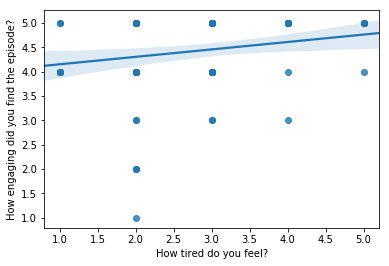

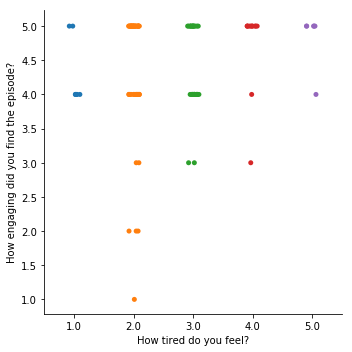

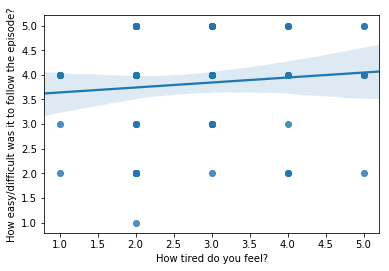

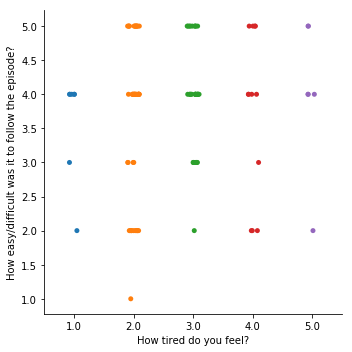

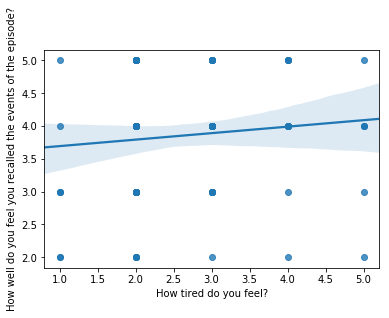

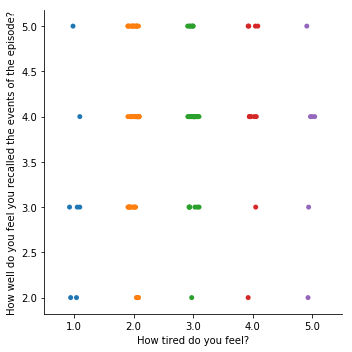

In [7]:
indcolslice = np.r_[21:24,28]
indcols = catdf.drop_duplicates('Subject ID', keep='last').drop('If yes above, describe', axis=1).columns[indcolslice]
depcols = catdf.drop_duplicates('Subject ID', keep='last').drop('If yes above, describe', axis=1).columns[24:27]
for indcol in indcols:
    for i, depcol in enumerate(depcols):
        plt.figure(i)
        sns.regplot(x=catdf[indcol].astype(float), y=catdf[depcol].astype(float), data=catdf)
        sns.catplot(x=indcol, y=depcol, data=catdf)
        plt.show()

## responses between responses across both sessions

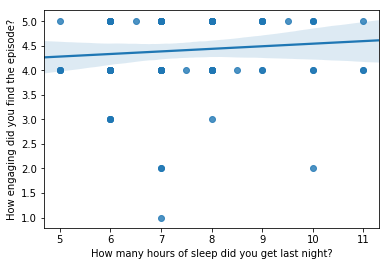

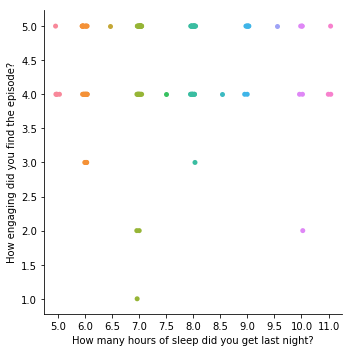

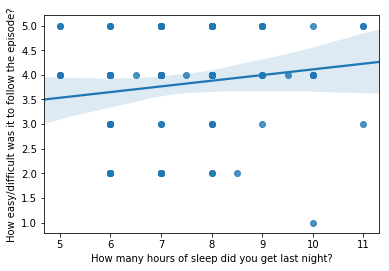

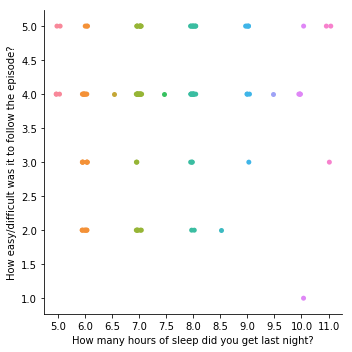

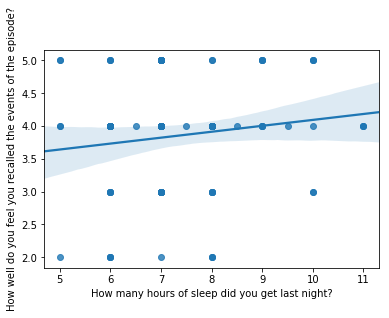

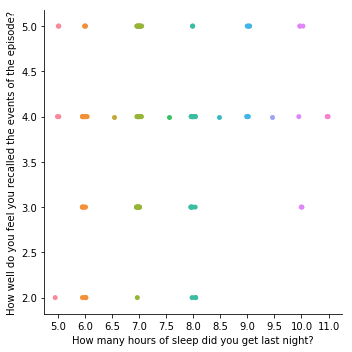

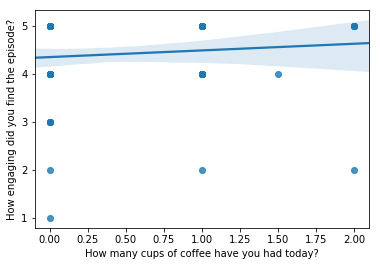

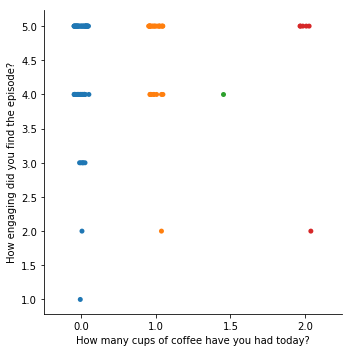

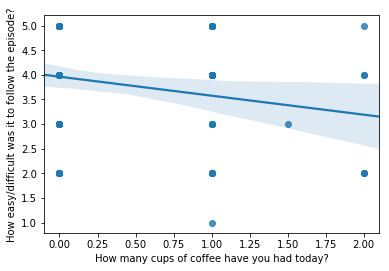

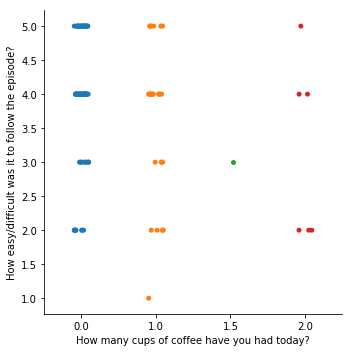

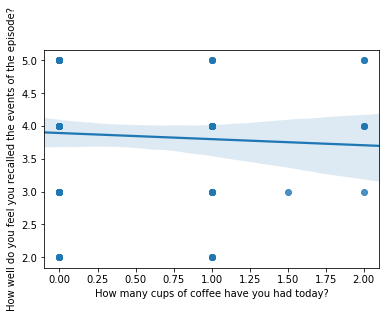

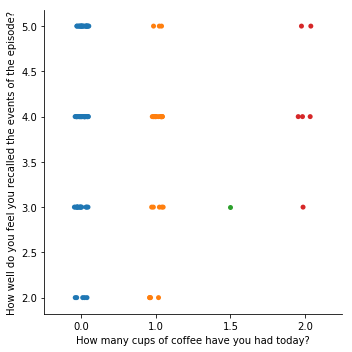

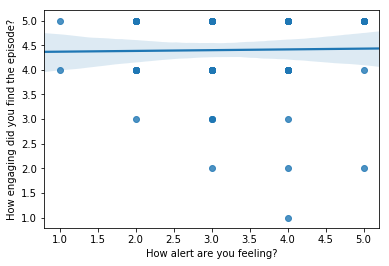

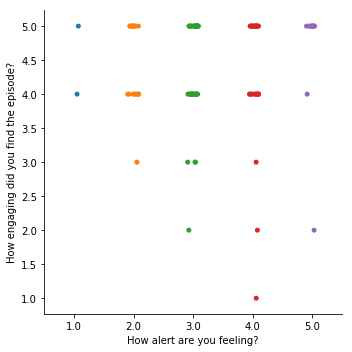

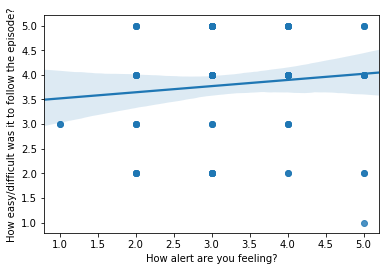

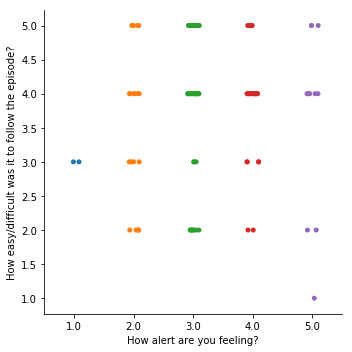

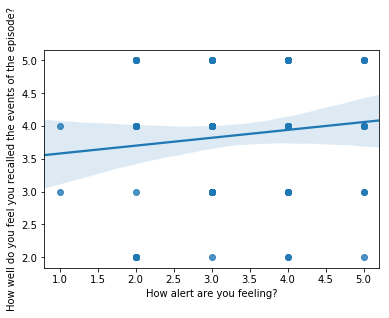

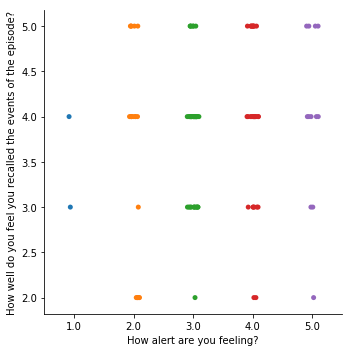

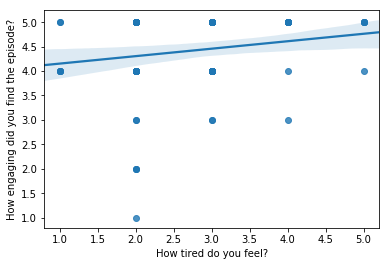

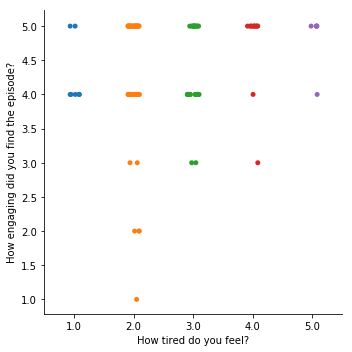

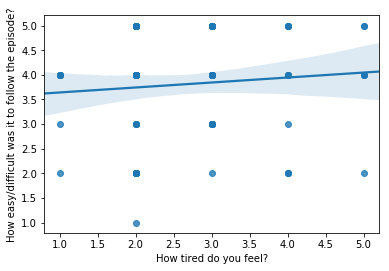

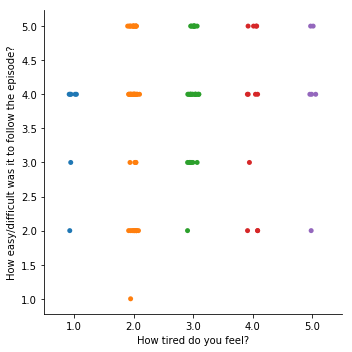

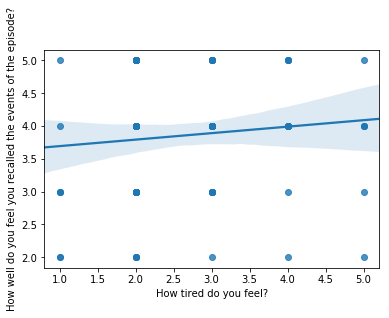

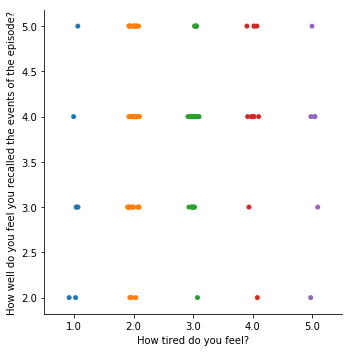

In [8]:
indcolslice = np.r_[21:24,28]
indcols = catdf.drop('If yes above, describe', axis=1).columns[indcolslice]
depcols = catdf.drop('If yes above, describe', axis=1).columns[24:27]
for indcol in indcols:
    for i, depcol in enumerate(depcols):
        plt.figure(i)
        sns.regplot(x=catdf[indcol].astype(float), y=catdf[depcol].astype(float), data=catdf)
        sns.catplot(x=indcol, y=depcol, data=catdf)
        plt.show()

## responses between groups and sessions

In [9]:
ses1allc = catdf.drop_duplicates('Subject ID').reset_index(drop=True)
ses1condAc = catdf[catdf['Subject ID'].str.contains('A')].drop_duplicates('Subject ID').reset_index(drop=True)
ses1condBc = catdf[catdf['Subject ID'].str.contains('B')].drop_duplicates('Subject ID').reset_index(drop=True)
ses2condAc = catdf[catdf['Subject ID'].str.contains('A')].drop_duplicates('Subject ID',keep='last').reset_index(drop=True)
ses2condBc = catdf[catdf['Subject ID'].str.contains('B')].drop_duplicates('Subject ID',keep='last').reset_index(drop=True)

In [10]:
# isolate questions by session and condition
ses1all = expdf.drop_duplicates('Subject ID').reset_index(drop=True)
ses1condA = expdf[expdf['Subject ID'].str.contains('A')].drop_duplicates('Subject ID').reset_index(drop=True)
ses1condB = expdf[expdf['Subject ID'].str.contains('B')].drop_duplicates('Subject ID').reset_index(drop=True)
ses2condA = expdf[expdf['Subject ID'].str.contains('A')].drop_duplicates('Subject ID',keep='last').reset_index(drop=True)
ses2condB = expdf[expdf['Subject ID'].str.contains('B')].drop_duplicates('Subject ID',keep='last').reset_index(drop=True)

# do the same with integer scores
ses1allc = catdf.drop_duplicates('Subject ID').reset_index(drop=True)
ses1condAc = catdf[catdf['Subject ID'].str.contains('A')].drop_duplicates('Subject ID').reset_index(drop=True)
ses1condBc = catdf[catdf['Subject ID'].str.contains('B')].drop_duplicates('Subject ID').reset_index(drop=True)
ses2condAc = catdf[catdf['Subject ID'].str.contains('A')].drop_duplicates('Subject ID',keep='last').reset_index(drop=True)
ses2condBc = catdf[catdf['Subject ID'].str.contains('B')].drop_duplicates('Subject ID',keep='last').reset_index(drop=True)

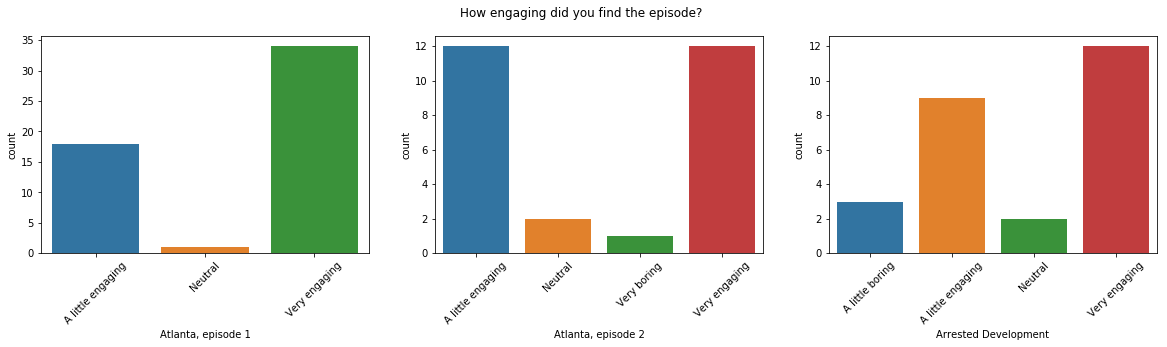

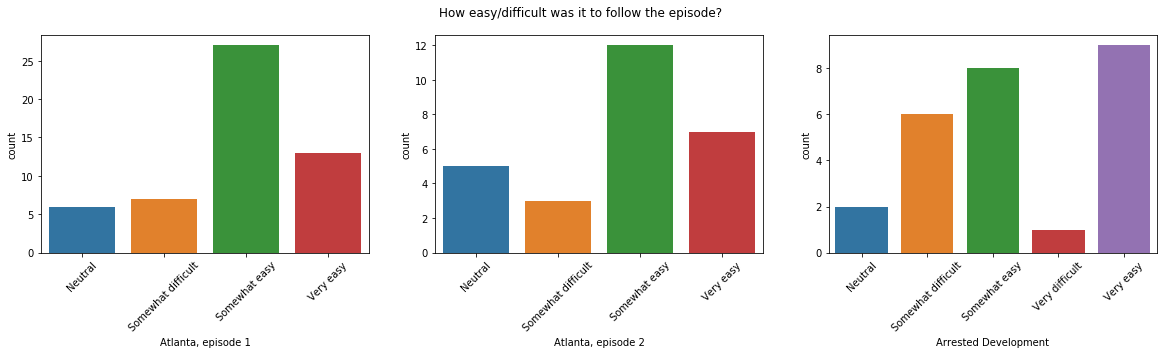

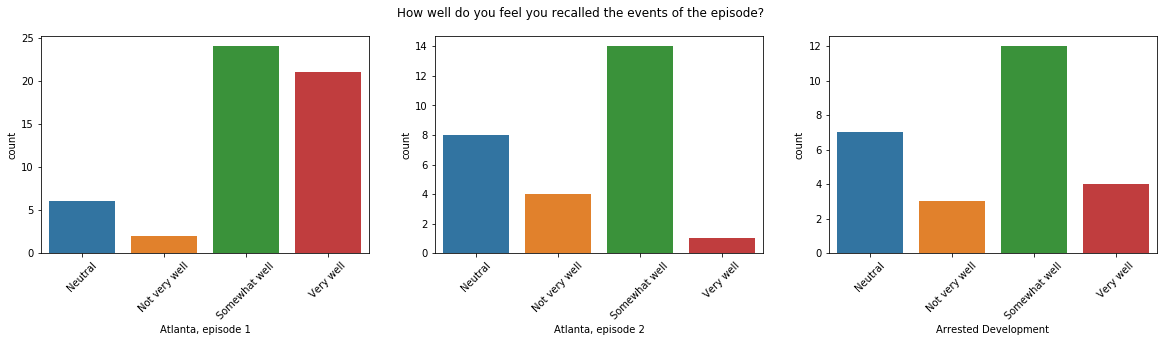

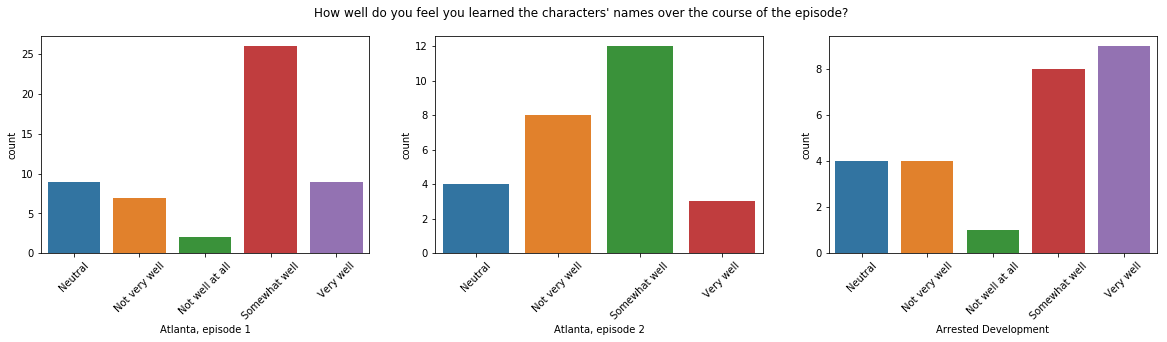

In [11]:
# are the engagement and memorabilities of the three stimuli sufficiently similar?
showtitles = ['Atlanta, episode 1', 'Atlanta, episode 2', 'Arrested Development']

for col in expdf.columns[26:30]:
    fig, ax = plt.subplots(1,3)
    fig.suptitle(col)
    for i, df in enumerate([ses1all, ses2condA, ses2condB]):
        plt.setp(ax[i].xaxis.get_majorticklabels(), rotation=45)
        fig.set_figwidth(20)
        fig.suptitle(col)
        sns.countplot(df[col].sort_values(), ax=ax[i]).set_xlabel(showtitles[i])

In [12]:
showtitles = ['Atlanta, episode 1', 'Atlanta, episode 2', 'Arrested Development']
meanrespdf = pd.DataFrame()

for col in expdf.columns[26:30]:
    for j, sescond in enumerate([ses1allc, ses2condAc, ses2condBc]):
        meanrespdf.loc[showtitles[j], col] = sescond[col].mean()

unstacked = meanrespdf.unstack().to_frame()

[Text(0,0.5,'Mean score')]

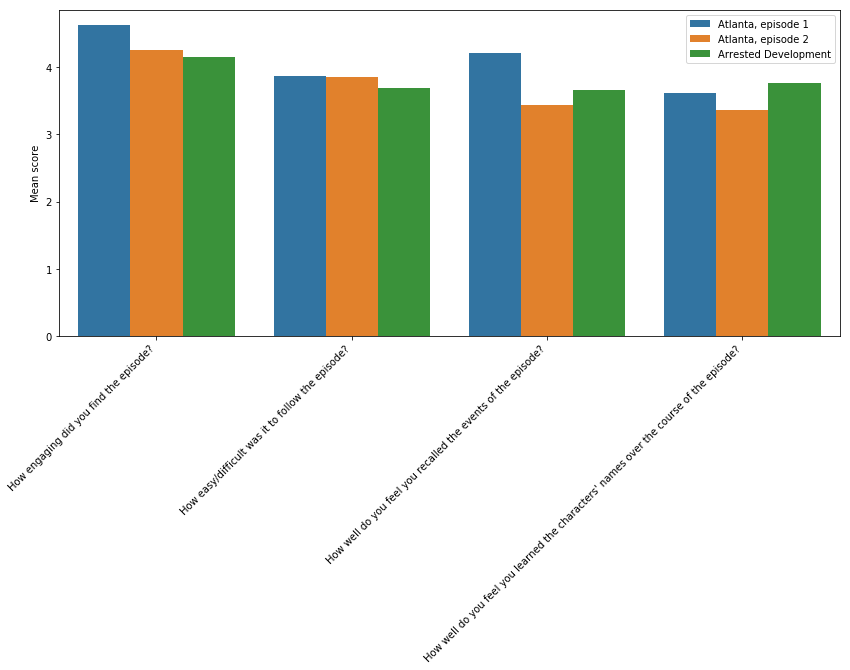

In [13]:
# same as above, but with numeric scores
plt.rcParams['figure.figsize']=(14, 6)
ax = sns.barplot(x=unstacked.index.get_level_values(0), y=unstacked[0], hue=unstacked.index.get_level_values(1))
plt.xticks(rotation=45, ha='right')
ax.set(ylabel='Mean score')